# Модуль 11. Языковые модели

Ноутбук к [модулю 11](https://drobyshevdev.github.io/lemma/modules/11-language-models/).

Модель здесь **символьная и строится подсчётом**, без обучения градиентом: цель — видеть каждый шаг и считать мгновенно. Принцип тот же, что у большой языковой модели — распределение следующего токена, — только токен здесь символ, а вероятности берутся из частот, а не из весов трансформера.

Нужны только `numpy` и `matplotlib`. **Читайте дважды:** сначала целиком, потом ломая.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

rng = np.random.default_rng(0)
np.set_printoptions(precision=3, suppress=True)

## 1. Корпус и словарь

Маленький корпус, чтобы всё считалось мгновенно и было видно руками. Словарь — просто множество встретившихся символов.

In [2]:
CORPUS = (
    "утверждение без базы сравнения пусто. число из одного запуска не свойство метода, "
    "а одно наблюдение случайной величины. поменяйте зерно генератора, и число изменится. "
    "поэтому меряют не одно значение, а распределение: среднее, разброс, доверительный интервал. "
    "если интервалы двух методов перекрываются, разница не показана, данных мало. "
    "модель предсказывает следующий символ по предыдущим. правильный ответ уже лежит в тексте, "
    "разметка не нужна: метку вырезают из данных сдвигом на один символ. "
    "перплексия говорит, во скольких вариантах модель колеблется на каждом шаге. "
    "низкая перплексия не значит польза: модель хорошо предсказывает текст, а не помогает. "
    "температура острит или размазывает распределение перед выборкой. "
    "бенчмарк, попавший в обучение, это утечка: высокий балл означает память, а не способность. "
) * 3

# Отдельный пробный текст для раздела про загрязнение: другое содержание, тот же
# язык. Модель его не видела, если специально не подмешать в обучение.
PROBE = ("эйнштейн опубликовал общую теорию относительности в тысяча девятьсот "
         "пятнадцатом году, объединив гравитацию с геометрией пространства и времени.")

chars = sorted(set(CORPUS + PROBE))
V = len(chars)
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}
print("длина корпуса:", len(CORPUS), " размер словаря:", V)

split = int(len(CORPUS) * 0.85)
train, test = CORPUS[:split], CORPUS[split:]
print("train:", len(train), " test:", len(test))

длина корпуса: 2436  размер словаря: 35
train: 2070  test: 366


## 2. Модель по счётчикам

Для контекста длины `order` считаем, какой символ шёл следом и сколько раз. Сглаживание add-alpha не даёт нулевых вероятностей. Незнакомый контекст откатывается к маргинальному распределению символов — это грубый бэкофф, но честный.

In [3]:
def marginal_dist(text, alpha=0.1):
    c = np.zeros(V)
    for ch in text:
        c[stoi[ch]] += 1
    return (c + alpha) / (c.sum() + alpha * V)

def build(text, order, alpha=0.1):
    """Возвращает таблицу контекст -> распределение следующего символа."""
    counts = defaultdict(lambda: np.zeros(V))
    for i in range(order, len(text)):
        counts[text[i - order:i]][stoi[text[i]]] += 1
    tables = {ctx: (c + alpha) / (c.sum() + alpha * V) for ctx, c in counts.items()}
    return tables

marg = marginal_dist(train)

def prob_of(tables, ctx):
    return tables.get(ctx, marg)

tables3 = build(train, order=3)
print("контекстов длины 3 в train:", len(tables3))
print("после 'мод' вероятнее всего:", repr(itos[prob_of(tables3, "мод").argmax()]))

контекстов длины 3 в train: 551
после 'мод' вероятнее всего: 'е'


## 3. Перплексия

Экспонента средней кросс-энтропии. Читается как число равновероятных вариантов, между которыми модель колеблется на каждом шаге.

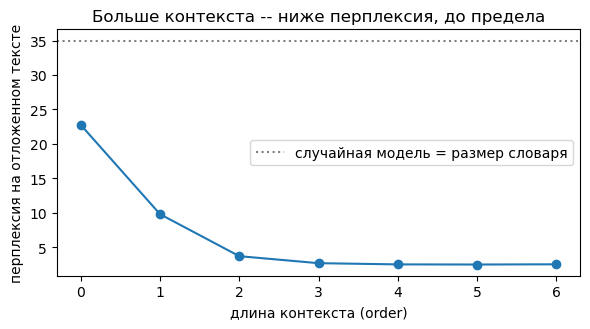

биграмма (order 1): PPL = 9.81
триграмма (order 2): PPL = 3.72
минимум на order = 5


In [4]:
def perplexity(tables, text, order):
    logs = []
    for i in range(order, len(text)):
        p = prob_of(tables, text[i - order:i])[stoi[text[i]]]
        logs.append(-np.log(p))
    return float(np.exp(np.mean(logs)))

orders = [0, 1, 2, 3, 4, 5, 6]
ppl_test = []
for k in orders:
    t = build(train, order=k) if k > 0 else {}
    # order 0 -- маргинальное распределение на всех позициях
    if k == 0:
        logs = [-np.log(marg[stoi[ch]]) for ch in test]
        ppl_test.append(float(np.exp(np.mean(logs))))
    else:
        ppl_test.append(perplexity(t, test, k))

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(orders, ppl_test, "o-")
ax.set_xlabel("длина контекста (order)"); ax.set_ylabel("перплексия на отложенном тексте")
ax.set_title("Больше контекста -- ниже перплексия, до предела")
ax.axhline(V, ls=":", color="gray", label="случайная модель = размер словаря")
ax.legend(); plt.tight_layout(); plt.show()

print("биграмма (order 1): PPL = %.2f" % ppl_test[1])
print("триграмма (order 2): PPL = %.2f" % ppl_test[2])
print("минимум на order =", orders[int(np.argmin(ppl_test))])

Триграмма ниже биграммы: больше контекста — точнее предсказание. Но за некоторым порядком перплексия на отложенном тексте снова растёт: контекстов становится столько, что каждый встречается один раз, и модель запоминает train вместо закономерности. Это переобучение из [модуля 2](https://drobyshevdev.github.io/lemma/modules/02-data-and-probability/), в другой одежде.

**Сломать.** Увеличьте повтор корпуса (`* 3` -> `* 8`) и посмотрите, как минимум сдвигается вправо: больше данных — больше контекста можно позволить.

## 4. Генерация с температурой

Температура делит логиты перед softmax — та же ручка, что масштабировала внимание в модуле 10. Низкая делает выбор почти жадным, высокая размазывает распределение.

In [5]:
def generate(tables, order, n, T, seed=0):
    gen = rng if seed is None else np.random.default_rng(seed)
    out = list(train[:order])
    for _ in range(n):
        p = prob_of(tables, "".join(out[-order:]))
        logits = np.log(p + 1e-12) / T          # температура на логитах
        logits -= logits.max()
        pt = np.exp(logits); pt /= pt.sum()
        out.append(itos[gen.choice(V, p=pt)])
    return "".join(out)

for T in (0.3, 1.0, 1.6):
    print(f"T = {T}:  {generate(tables3, 3, 120, T, seed=1)!r}\n")

T = 0.3:  'утвет уже лежит из данных сдвигом наблюдение, разменяйте зерно генератора, и число из данных мало. модель пределение свойст'

T = 1.0:  'утвеы,щдесел поксдз,еавпвиэыокв.ьй нрну кз нсмвсиип,соратм тттив носланры.ител,оусто.пас с:едоае вевнениеенрекиябв впо пред'

T = 1.6:  'утвкьаьеитзм рлесеи:збгрдкюэрлдаюл.нснщ лй ощнгтллратучача:уухйд ортдвотэакчин,оътчовсбт твжепаз ги,ожроихотемгявг гсп:жиои'



При `T = 0.3` текст скатывается в повтор самых частых кусков — жадность душит. При `T = 1.6` рассыпается в случайные буквы. Рабочий диапазон между ними.

**Сломать.** Постройте модель порядка 5 и повторите. Более длинный контекст даёт более связный текст при той же температуре — ценой переобучения из раздела 3.

## 5. Квантизация

Веса модели — здесь это логиты таблиц — можно хранить в меньшем числе бит. Огрубляем логиты до `bits` уровней и смотрим, что делается с перплексией.

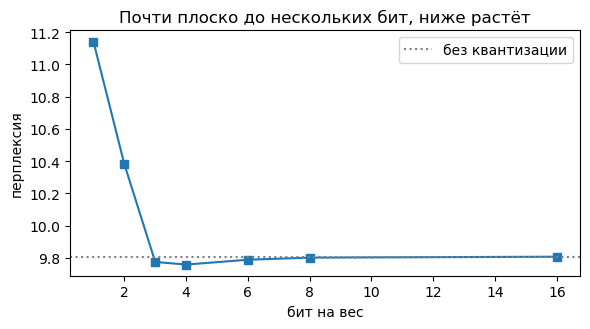

16 бит: PPL = 9.81    4 бита: 9.76    2 бита: 10.38    1 бит: 11.14


In [6]:
def quantize(arr, bits):
    lo, hi = arr.min(), arr.max()
    if hi == lo:
        return arr.copy()
    levels = 2 ** bits - 1
    q = np.round((arr - lo) / (hi - lo) * levels)
    return lo + q / levels * (hi - lo)

def quantized_tables(tables, bits):
    out = {}
    for ctx, p in tables.items():
        ql = quantize(np.log(p + 1e-12), bits)
        pe = np.exp(ql - ql.max()); pe /= pe.sum()
        out[ctx] = pe
    return out

# Биграмма: её распределения не такие острые, как у триграммы, поэтому огрубление
# логитов на ней видно. У почти детерминированной триграммы квантизация не кусает.
tables1 = build(train, order=1)
ppl_full1 = perplexity(tables1, test, 1)
bit_grid = [1, 2, 3, 4, 6, 8, 16]
ppl_bits = [perplexity(quantized_tables(tables1, b), test, 1) for b in bit_grid]

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(bit_grid, ppl_bits, "s-")
ax.axhline(ppl_full1, ls=":", color="gray", label="без квантизации")
ax.set_xlabel("бит на вес"); ax.set_ylabel("перплексия")
ax.set_title("Почти плоско до нескольких бит, ниже растёт")
ax.legend(); plt.tight_layout(); plt.show()

print("16 бит: PPL = %.2f    4 бита: %.2f    2 бита: %.2f    1 бит: %.2f"
      % (ppl_bits[-1], ppl_bits[3], ppl_bits[1], ppl_bits[0]))

Кривая почти не двигается до нескольких бит и медленно растёт ниже: старшие знаки в логитах избыточны, младшие — нет. На этой игрушечной модели эффект мал, потому что предсказания и так почти определённые; у настоящих весов запаса меньше, поэтому в ходу 8 и 4 бита, а 2 — уже редко и с ухищрениями.

**Сломать.** Квантуйте не логиты, а сами вероятности, и сравните. Рост начнётся раньше — логиты сжимаются в биты лучше, чем вероятности.

## 6. Утечка бенчмарка

Прямая связь с [модулем 7](https://drobyshevdev.github.io/lemma/modules/07-honest-comparison/). Если тест попал в обучение, высокий балл означает память, а не способность. Берём пробный текст с другим содержанием и меряем перплексию на нём у чистой модели и у модели, которой его подмешали в обучение.

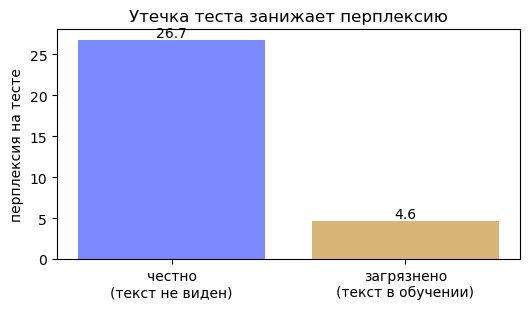

честно: 26.72    загрязнено: 4.62    занижение в 5.8 раза


In [7]:
clean = build(CORPUS, order=3)               # модель не видела пробный текст
dirty = build(CORPUS + PROBE, order=3)       # пробный текст подмешан в обучение

ppl_clean = perplexity(clean, PROBE, 3)
ppl_dirty = perplexity(dirty, PROBE, 3)

fig, ax = plt.subplots(figsize=(5.4, 3.2))
ax.bar(["честно\n(текст не виден)", "загрязнено\n(текст в обучении)"], [ppl_clean, ppl_dirty],
       color=["#7b8aff", "#d8b678"])
for i, v in enumerate([ppl_clean, ppl_dirty]):
    ax.text(i, v, f"{v:.1f}", ha="center", va="bottom")
ax.set_ylabel("перплексия на тесте")
ax.set_title("Утечка теста занижает перплексию")
plt.tight_layout(); plt.show()

print("честно: %.2f    загрязнено: %.2f    занижение в %.1f раза"
      % (ppl_clean, ppl_dirty, ppl_clean / ppl_dirty))

Загрязнённая модель показывает на тесте перплексию заметно ниже — не потому, что лучше, а потому, что видела ответы. На лидербордах языковых моделей это происходит незаметно: обучающий корпус закрыт, а тесты лежат в том же интернете, откуда он собран.

**Сломать.** Подмешайте в обучение только половину пробного текста и померьте перплексию отдельно на виденной и невиданной половине. Разрыв покажет загрязнение точнее среднего по всему тексту.

## Что дальше

Обучение на предпочтениях из этого модуля — это уже обучение с подкреплением: «лучше» стало наградой. [Часть IV](https://drobyshevdev.github.io/lemma/programme/) вводит среду, награду и политику, а взлом награды, которого мы коснулись, станет там отдельной темой.

И тот же вопрос, что во всём курсе: заявленное превосходство языковой модели переживает смену промпта, честную базу и проверку на утечку теста — или это память, выданная за способность?